In [76]:
import pandas as pd

# Uber Cardinality


In [77]:
results_df =  pd.read_csv(r'C:\Users\Ronza\Dev\DP-MSD\Uber\results\results_from_server\Uber_Master_Results_1000_800.csv')

In [78]:
results_df


,alg,k,lambda_param,eps,rep,value,relevance,diversity,queries,time_sec
0,nonpriv,4,0.1,0.1,0,0.892534,0.936050,0.500891,7990,0.5593
1,DPGreedy,4,0.1,0.1,0,0.892534,0.936050,0.500891,7990,0.9356
2,DPSampleOblGreedy,4,0.1,0.1,0,0.891032,0.937908,0.469144,4612,0.6777
3,DPSampleGreedy,4,0.1,0.1,0,0.891890,0.935334,0.500891,5610,0.8399
4,Random,4,0.1,0.1,0,0.815586,0.867832,0.345375,0,0.0009
...,...,...,...,...,...,...,...,...,...,...
1195,nonpriv,6,0.8,0.1,9,0.650672,0.906247,0.586779,11972,0.8037
1196,DPGreedy,6,0.8,0.1,9,0.618908,0.889015,0.551381,11972,1.5985
1197,DPSampleOblGreedy,6,0.8,0.1,9,0.633778,0.906929,0.565490,4612,0.7052
1198,DPSampleGreedy,6,0.8,0.1,9,0.605803,0.874558,0.538615,7028,0.9871


## Impact of k on score


In [79]:
results_df['alg'] = results_df['alg'].replace(
    {
        'nonpriv': 'Greedy',
        'DPGreedy': 'DP-Greedy',
        'DPSampleOblGreedy': 'DP-OSG',
        'DPSampleGreedy': 'DP-NOSG',
        'Random': 'Random'
    }
)

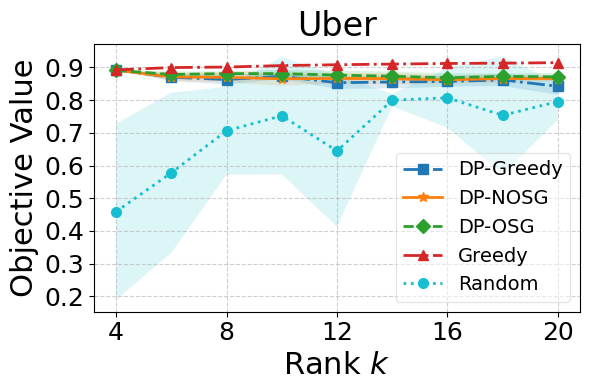

In [93]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[(results_df['eps'] == 0.1) & (results_df['lambda_param'] == 0.1)]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    

    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
)
    plt.fill_between(
        alg_data['k'], 
        alg_data['mean'] - alg_data['std'], 
        alg_data['mean'] + alg_data['std'], 
        color=line.get_color(),
        alpha=0.15,  # Low alpha for transparency
        edgecolor='none' # No border around the shade for a softer look
    )
# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Uber', fontsize=24)

plt.xticks(range(4, 22, 4), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5) # Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('uber_cardinality_k_on_val.pdf')
plt.show()

## Impact of eps on score

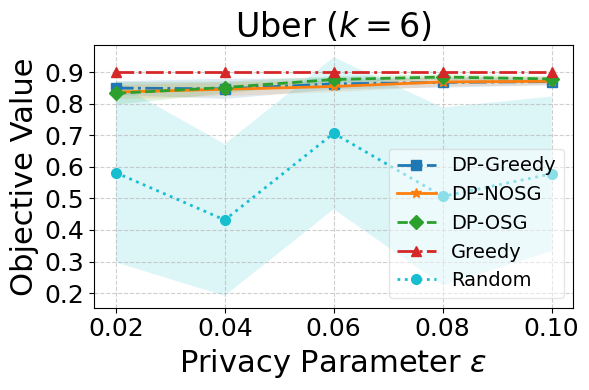

In [89]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 6 
eps_list = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]

filtered_df = results_df[
    (results_df['k'] == target_k) & 
    (results_df['lambda_param'] == 0.1) & 
    (results_df['eps'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'eps'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    line, = plt.plot(
        alg_data['eps'], 
        alg_data['mean'], 
        label=alg,
        color=colors[i % len(colors)],
        marker=markers[i % len(markers)],
        linestyle=linestyles[i % len(linestyles)],
        linewidth=2,
        markersize=7
        )
    plt.fill_between(
        alg_data['eps'], 
        alg_data['mean'] - alg_data['std'], 
        alg_data['mean'] + alg_data['std'], 
        color=line.get_color(),
        alpha=0.15,  # Low alpha for transparency
        edgecolor='none' # No border around the shade for a softer look
         )
    

# Formatting with exact fontsizes from your reference
plt.xlabel('Privacy Parameter $\\varepsilon$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Uber ($k=6$)', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(eps_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5, loc='lower right')# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('uber_cardinality_eps_on_val.pdf')
plt.show()

## Impact of k on num queries

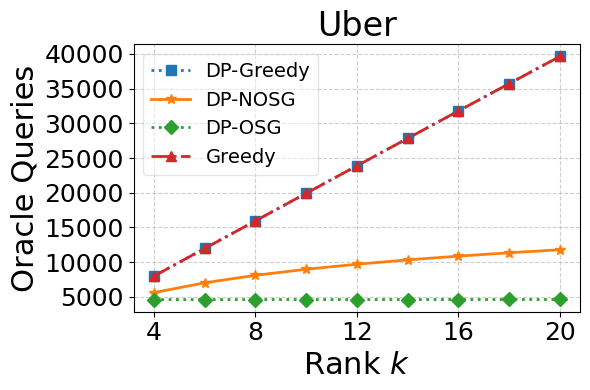

In [82]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[
    (results_df['eps'] == 0.1) 
    & (results_df['lambda_param'] == 0.1) 
    & results_df['k'].isin(list(range(4, 22, 2)))
    & ~results_df['alg'].isin(['Random'])
    
]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['queries'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )


# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Oracle Queries', fontsize=22)
plt.title('Uber', fontsize=24)

plt.xticks(range(4, 22, 4), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('uber_k_on_queries.pdf')
plt.show()

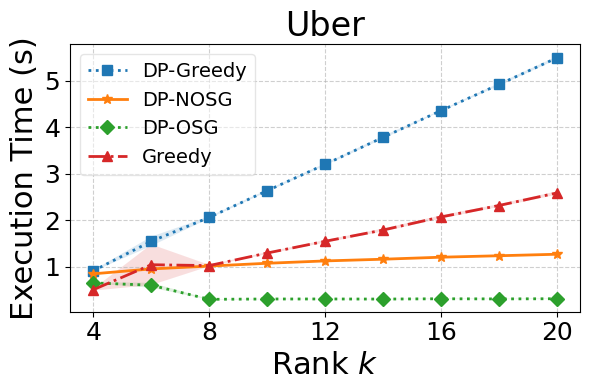

In [83]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Filter the data for eps=0.1 and lambda_param=0.1
# Using your initial filtering requirements
filtered_df = results_df[
    (results_df['eps'] == 0.1) 
    & (results_df['lambda_param'] == 0.1) 
    & results_df['k'].isin(list(range(4, 22, 2)))
    & ~results_df['alg'].isin(['Random'])
    
]

# 2. Group by algorithm and 'k' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'k'])['time_sec'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with large text and distinct styles
plt.figure(figsize=(6, 4)) # Large figure size for clarity

# Define specific styles to ensure variety across algorithms
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = [':', '-', ':', '-.', '-', '--']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

# Get the list of algorithms present in the stats
algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    # Assign a unique combination of color, marker, and linestyle to each alg
    line, = plt.plot(
    alg_data['k'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['k'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )


# Formatting for large text relative to the image size
plt.xlabel('Rank $k$', fontsize=22)
plt.ylabel('Execution Time (s)', fontsize=22)
plt.title('Uber', fontsize=24)

plt.xticks(range(4, 22, 4), fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Legend with a box for clarity
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() # Ensures labels don't get cut off
plt.savefig('uber_k_on_time.pdf')
plt.show()

## Impact of lambda on score

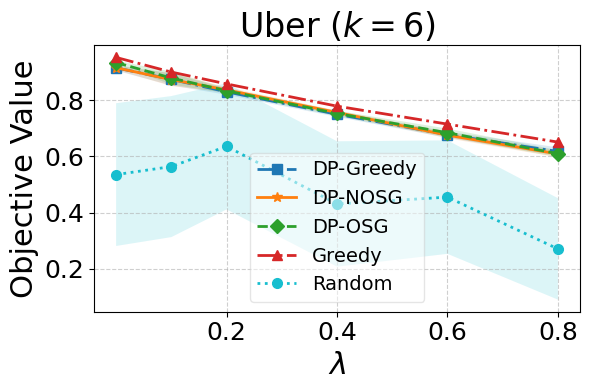

In [106]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Filter the data for k=15 and lambda_param=0.1
target_k = 6
lambda_list = [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

filtered_df = results_df[
    (results_df['k'] == target_k) 
    # (results_df['lambda_param'].round(2).isin(eps_list)) 
]

# 2. Group by algorithm and 'eps' to get average and standard deviation
stats = filtered_df.groupby(['alg', 'lambda_param'])['value'].agg(['mean', 'std']).reset_index()

# 3. Create the plot with your exact requested sizes
plt.figure(figsize=(6, 4)) # Exact size from your reference

# Define specific styles
markers = ['s', '*', 'D', '^', 'o', 'x']
linestyles = ['-.', '-', '--', '-.', ':']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#17becf', '#8c564b']

algorithms = stats['alg'].unique()

for i, alg in enumerate(algorithms):
    alg_data = stats[stats['alg'] == alg]
    
    line, = plt.plot(
    alg_data['lambda_param'], 
    alg_data['mean'], 
    label=alg,
    color=colors[i % len(colors)],
    marker=markers[i % len(markers)],
    linestyle=linestyles[i % len(linestyles)],
    linewidth=2,
    markersize=7
    )
    plt.fill_between(
    alg_data['lambda_param'], 
    alg_data['mean'] - alg_data['std'], 
    alg_data['mean'] + alg_data['std'], 
    color=line.get_color(),
    alpha=0.15,  # Low alpha for transparency
    edgecolor='none' # No border around the shade for a softer look
     )    
    # plt.errorbar(
    #     alg_data['eps'], 
    #     alg_data['mean'], 
    #     yerr=alg_data['std'], 
    #     label=alg,
    #     color=colors[i % len(colors)],
    #     marker=markers[i % len(markers)],
    #     linestyle=linestyles[i % len(linestyles)],
    #     linewidth=2.5,  
    #     markersize=6,   # Exact size from your reference
    #     capsize=6       
    # )

# Formatting with exact fontsizes from your reference
plt.xlabel('$\\lambda$', fontsize=22)
plt.ylabel('Objective Value', fontsize=22)
plt.title('Uber ($k=6$)', fontsize=24)

# Show only even ticks to avoid crowding: 0.02, 0.04, 0.06, 0.08, 0.10
plt.xticks(lambda_list[1::2], fontsize=18)
plt.yticks(fontsize=18)

plt.legend(fontsize=14, frameon=True, ncols=1, framealpha=0.5)# Exact size from your reference
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout() 
plt.savefig('uber_cardinality_lambda_on_val.pdf')
plt.show()